# Baseline Model — TF-IDF + Logistic Regression

This notebook implements a **classical NLP baseline** for hallucination detection using a sparse TF-IDF representation and a linear classifier.

## Objective
Given a *(prompt, response)* pair, predict whether the response is **hallucinatory** (`label=1`) or **non-hallucinatory** (`label=0`).

## Why a TF-IDF baseline?
- **Fast & reproducible**: trains quickly on CPU and is easy to rerun.
- **Interpretable**: strong n-grams can be inspected to understand common failure modes.
- **Reference point**: establishes a lower bound before moving to richer models (numeric features, embeddings, transformers).

## Project integration
We rely on repository utilities:
- `src.data.load_splits.load_splits` to load the processed train/val/test splits.
- `src.utils.eval.evaluate_split` to compute consistent metrics across notebooks.


In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo root:", ROOT)
print("src exists:", (ROOT / "src").exists())


Repo root: /Users/aviv.gross/hallu-detect
src exists: True


In [2]:
# Core
import pandas as pd
import numpy as np

# ML / NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import confusion_matrix, roc_auc_score
from src.utils.eval import evaluate_split

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 200)

# Ensure repo root is in PYTHONPATH
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Use explicit import to avoid module/function confusion
from src.data.load_splits import load_splits

train_df, val_df, test_df = load_splits(root=ROOT)
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)


Train: (51647, 7)
Val:   (6425, 7)
Test:  (6435, 7)


## Build a single text field (Prompt + Response)

TF-IDF and other bag-of-words methods operate on **one text input per example**.  
To include the context in which a response was generated, we concatenate the two fields:

\[
x = \text{prompt} \; + \; \text{separator} \; + \; \text{response}
\]

### Why combine them?
Hallucination is often **context-dependent**:
- A response can be “true” in general, but **wrong for a specific prompt**.
- Many hallucination cues appear as **inconsistencies** between question and answer.

This baseline can learn shallow lexical patterns correlated with mismatches, even though it cannot truly verify facts.


In [3]:
def build_text(df: pd.DataFrame) -> pd.Series:
    """Combine prompt and response into a single text field."""
    return df["prompt"].fillna("").astype(str) + "\n\n" + df["response"].fillna("").astype(str)

X_train_text = build_text(train_df)
X_val_text   = build_text(val_df)
X_test_text  = build_text(test_df)

y_train = train_df["label"].astype(int)
y_val   = val_df["label"].astype(int)
y_test  = test_df["label"].astype(int)

print("Text ready:", X_train_text.shape, X_val_text.shape, X_test_text.shape)


Text ready: (51647,) (6425,) (6435,)


In [4]:
# Quick sanity check: show before/after for 2 rows
tmp = train_df.sample(2, random_state=42)[["task","label","prompt","response"]].copy()
tmp["combined_text"] = build_text(tmp)
tmp[["task","label","combined_text"]]


,task,label,combined_text
13005,dialogue,1,"[Human]: Do you like Will Smith? [Assistant]: Absolutely! I love The Pursuit of Happyness. Have you seen it? [Human]: Maybe did he kill his self in the end to save others? \n\nYes, he killed himse..."
36568,summarization,0,Three people have been killed after clubbers stampeded into a nightclub to see a British punk band called Doom. The crowd tried to storm the club Tsunami in the Chilean capital Santiago. The band ...


## Vectorize text with TF-IDF

We compute TF-IDF features over unigrams and bigrams (1–2 grams).
The result is a high-dimensional sparse matrix used as input to the classifier.
Vectorize

In [5]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=100_000,
    ngram_range=(1, 2),
    min_df=2
)

X_train = vectorizer.fit_transform(X_train_text)
X_val   = vectorizer.transform(X_val_text)
X_test  = vectorizer.transform(X_test_text)

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)


X_train: (51647, 100000) | X_val: (6425, 100000) | X_test: (6435, 100000)


## Train a Logistic Regression classifier

We train a linear classifier on the TF-IDF matrix.
Class imbalance is handled via `class_weight='balanced'`.


In [6]:
clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

clf.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## Evaluate on Validation and Test

We report standard classification metrics on the validation split (for model selection)
and on the held-out test split (final reporting). Metrics are computed via `evaluate_split`
for consistency across the project.


In [7]:
val_metrics  = evaluate_split("val", clf, X_val, y_val)
test_metrics = evaluate_split("test", clf, X_test, y_test)



val metrics:
  accuracy = 0.6378
  f1       = 0.6239
  precision= 0.6007
  recall   = 0.6490
  confusion matrix:
[[2168 1283]
 [1044 1930]]

test metrics:
  accuracy = 0.6452
  f1       = 0.6242
  precision= 0.6134
  recall   = 0.6354
  confusion matrix:
[[2256 1195]
 [1088 1896]]


## ROC-AUC

ROC-AUC evaluates ranking quality across thresholds using predicted probabilities (not hard labels).


In [8]:
y_val_prob = clf.predict_proba(X_val)[:, 1]
print("VAL roc_auc:", roc_auc_score(y_val, y_val_prob))


VAL roc_auc: 0.712723737084287


## Confusion Matrix

A confusion matrix visualizes true/false positives and negatives on the validation split.


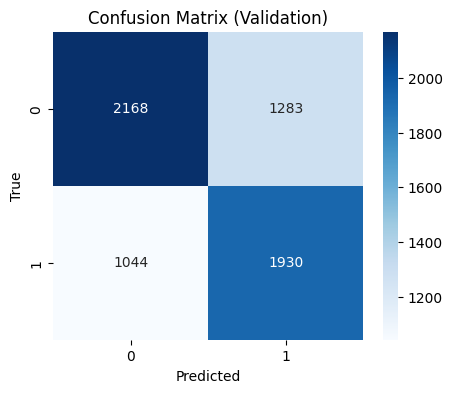

In [9]:
y_val_pred = clf.predict(X_val)
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
